# CorCLV - uscrime dataset

In [1]:
# disable warnings
from warnings import simplefilter, filterwarnings
simplefilter(action='ignore', category=FutureWarning)
filterwarnings("ignore")

## uscrime dataset

In [2]:
# poison dataset
from clustvartools.datasets import uscrime
data = uscrime.data
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crime.rate       47 non-null     float64
 1   Male14_24        47 non-null     int64  
 2   Southern.states  47 non-null     int64  
 3   Education        47 non-null     int64  
 4   Expend60         47 non-null     int64  
 5   Expend59         47 non-null     int64  
 6   Labor.force      47 non-null     int64  
 7   Male             47 non-null     int64  
 8   Pop.size         47 non-null     int64  
 9   Non.white        47 non-null     int64  
 10  Unemp14_24       47 non-null     int64  
 11  Unemp35_39       47 non-null     int64  
 12  Family.Income    47 non-null     int64  
 13  Under.median     47 non-null     int64  
dtypes: float64(1), int64(13)
memory usage: 5.3 KB


## Instanciation and training

In [3]:
# instanciation
from clustvartools import CorCLV
clf = CorCLV(ncl=4,sup_var=0)

### `fit` function

In [4]:
# fit function
clf.fit(data)

,ncl,4
,sup_var,0
,kind,'cor'
,method,'pearson'
,precomputed,False
Name,Type,Value
call_,call,call(Xtot= ...'Crime.rate'])
quanti_var_,quanti_var,quanti_var(cl... 0.214684)
quanti_var_sup_,quanti_var_sup,quanti_var_su... 0.538755)


### `fit_transform` function

In [5]:
# fit_transform function - squared loadings
sqload = clf.fit_transform(data)
sqload

,1,2,3,4
Male14_24,0.873760,0.657702,0.966623,0.343688
Southern.states,0.993079,0.841515,0.618636,0.214147
Education,0.974107,0.765272,0.504088,0.218248
Expend60,0.986528,0.043478,0.977368,0.598075
Expend59,0.990657,0.048329,0.984137,0.583953
Labor.force,0.778977,0.994817,0.131808,0.786940
Male,0.928257,0.981283,0.131808,0.897390
Pop.size,0.964058,0.347417,0.792458,0.979413
Non.white,0.996097,0.963505,0.718806,0.257492
Unemp14_24,0.078531,0.995680,0.979853,0.978663


### `transform` function

In [6]:
# transform function
sqload = clf.transform(uscrime.actif)
sqload

,1,2,3,4
Male14_24,1.747520,1.315404,1.933247,0.687376
Southern.states,1.986158,1.683031,1.237272,0.428295
Education,1.948214,1.530545,1.008176,0.436496
Expend60,1.973056,0.086955,1.954737,1.196149
Expend59,1.981314,0.096658,1.968274,1.167906
Labor.force,1.557953,1.989635,0.263615,1.573880
Male,1.856514,1.962566,0.263615,1.794781
Pop.size,1.928116,0.694833,1.584916,1.958826
Non.white,1.992193,1.927010,1.437612,0.514984
Unemp14_24,0.157063,1.991360,1.959707,1.957327


### `fit_predict` function

In [7]:
# fit_predict function
prediction = clf.fit_predict(data)
prediction.to_frame()

,cluster
Male14_24,4
Southern.states,4
Education,4
Expend60,2
Expend59,2
Labor.force,3
Male,3
Pop.size,2
Non.white,4
Unemp14_24,1


### `predict` function

In [8]:
# predict function
prediction = clf.predict(uscrime.actif)
prediction.to_frame()

,cluster
Male14_24,4
Southern.states,4
Education,4
Expend60,2
Expend59,2
Labor.force,3
Male,3
Pop.size,2
Non.white,4
Unemp14_24,1


In [9]:
# attributes
from clustvartools import sprintf
sprintf(clf)


**Clustering of Variables - CorCLV**

*The results are available in the following objects:

name              description
----------------  --------------------------------------------------
.call_            summary called parameters
.quanti_var_      results for the continuous variables
.quanti_var_sup_  results for the supplementary continuous variables



## Variables informations

In [10]:
# variables informations
var_ = clf.quanti_var_
var_._fields

('cluster', 'diss', 'member')

### Cluster dissimilarities

In [11]:
# cluster dissimilarities
var_.diss

,1,2,3,4
Male14_24,0.873760,0.657702,0.966623,0.343688
Southern.states,0.993079,0.841515,0.618636,0.214147
Education,0.974107,0.765272,0.504088,0.218248
Expend60,0.986528,0.043478,0.977368,0.598075
Expend59,0.990657,0.048329,0.984137,0.583953
Labor.force,0.778977,0.994817,0.131808,0.786940
Male,0.928257,0.981283,0.131808,0.897390
Pop.size,0.964058,0.347417,0.792458,0.979413
Non.white,0.996097,0.963505,0.718806,0.257492
Unemp14_24,0.078531,0.995680,0.979853,0.978663


### Cluster member

In [12]:
# cluster member
var_.member.sort_values(by=["Cluster","Variable"])

,Variable,Cluster,Own Cluster,Next Closest,Ratio (Own/Next)
9,Unemp14_24,1,0.078531,0.978663,0.080243
10,Unemp35_39,1,0.078531,0.840407,0.093444
4,Expend59,2,0.048329,0.583953,0.082762
3,Expend60,2,0.043478,0.598075,0.072696
7,Pop.size,2,0.347417,0.792458,0.438404
5,Labor.force,3,0.131808,0.778977,0.169206
6,Male,3,0.131808,0.89739,0.146879
2,Education,4,0.218248,0.504088,0.432956
11,Family.Income,4,0.18275,0.358803,0.50933
0,Male14_24,4,0.343688,0.657702,0.522559


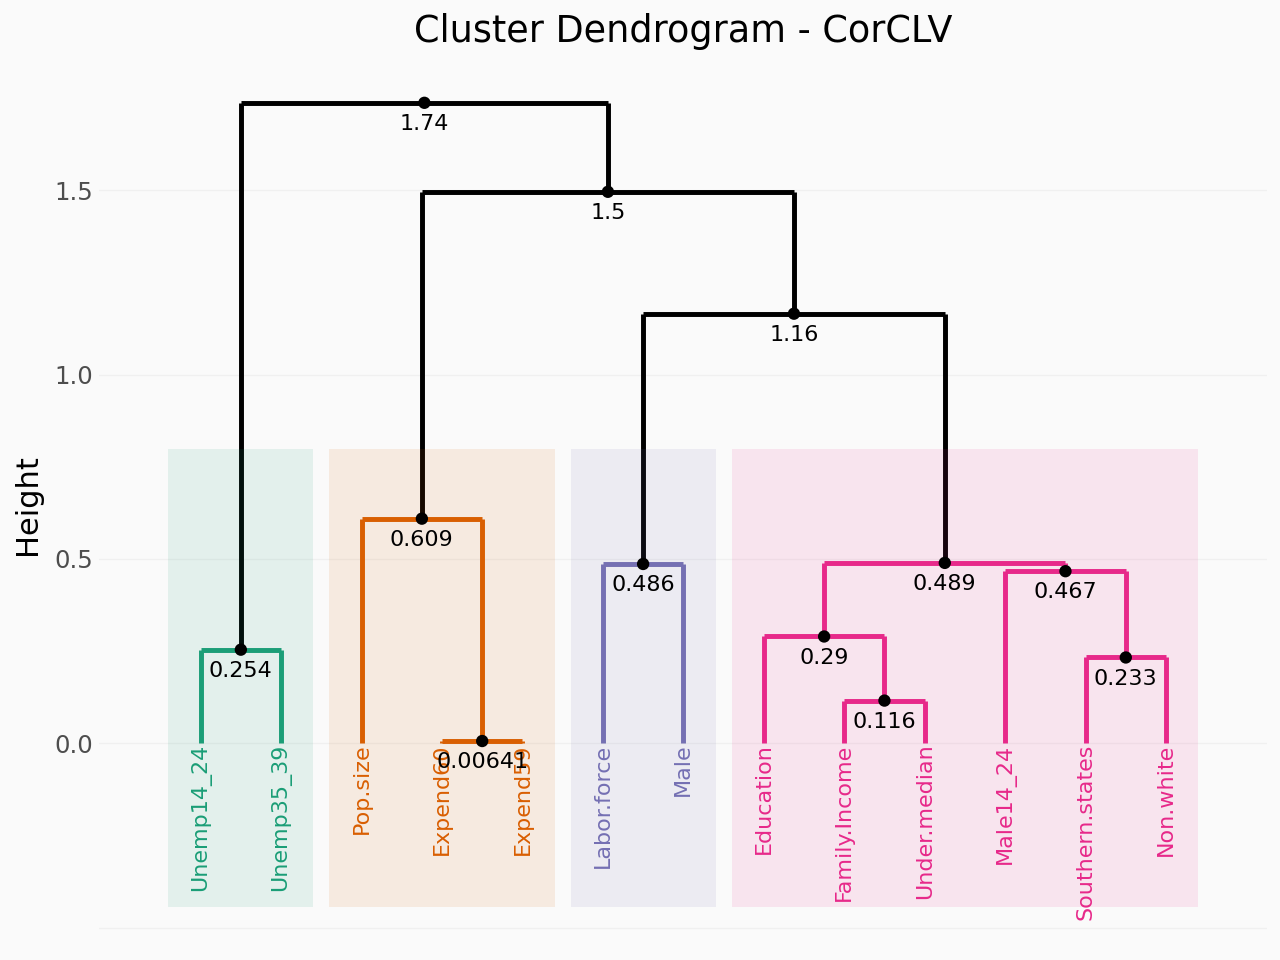

None


In [13]:
# dendrogram
from clustvartools import fviz_dend, fviz_height
p = fviz_dend(obj=clf,
              rect=True,
              rect_fill=True,
              color_labels_by_cluster=True,
              text_size=8,
              text_height=True,
              nudge_y=-0.03)
print(p.show())

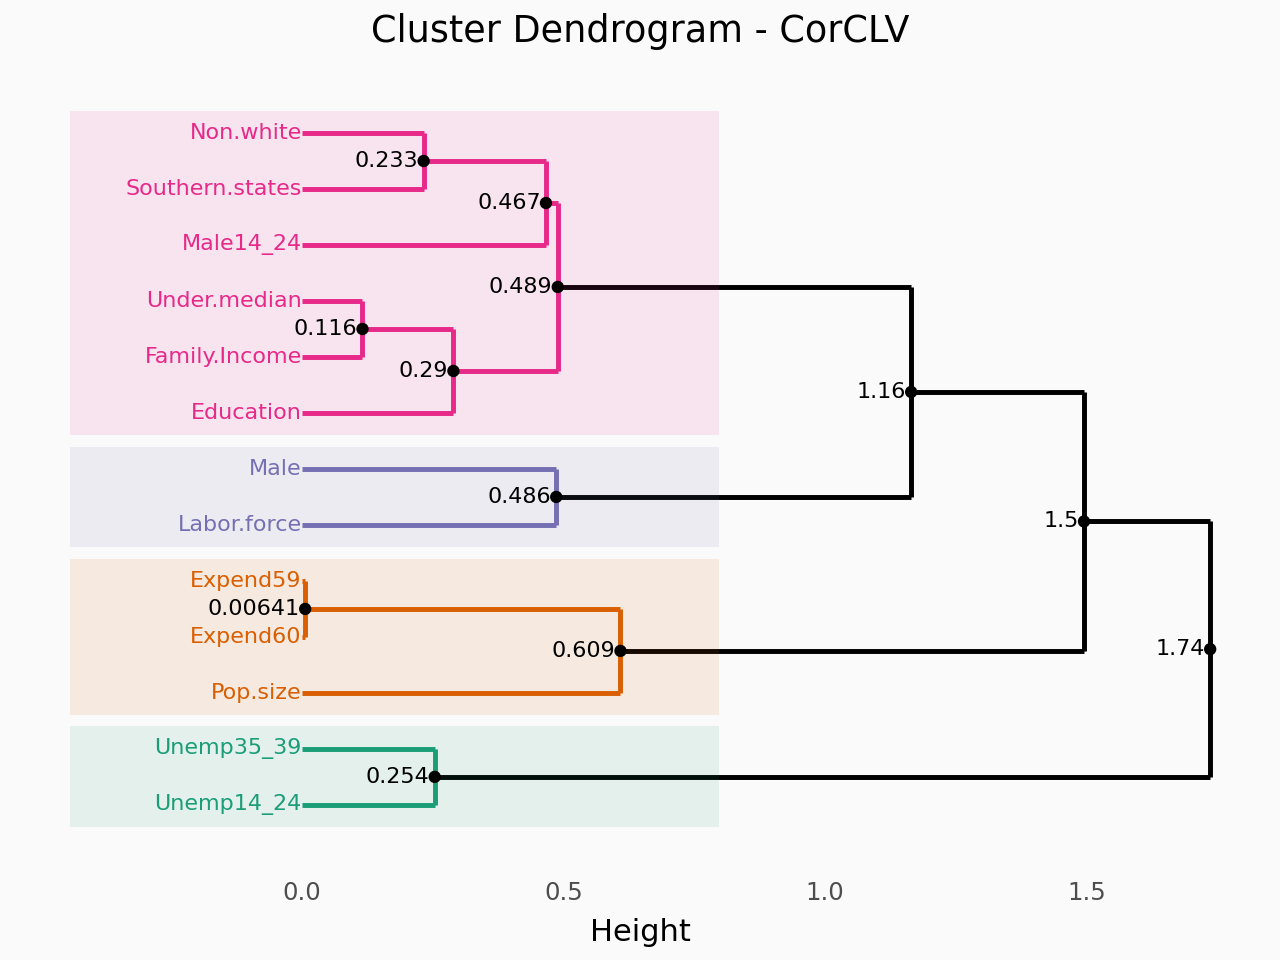

None


In [14]:
# horizon 
p = fviz_dend(obj=clf,
              horiz=True,
              rect=True,
              rect_fill=True,
              color_labels_by_cluster=True,
              text_size=8,
              text_height=True,
              nudge_x=-0.01)
print(p.show())

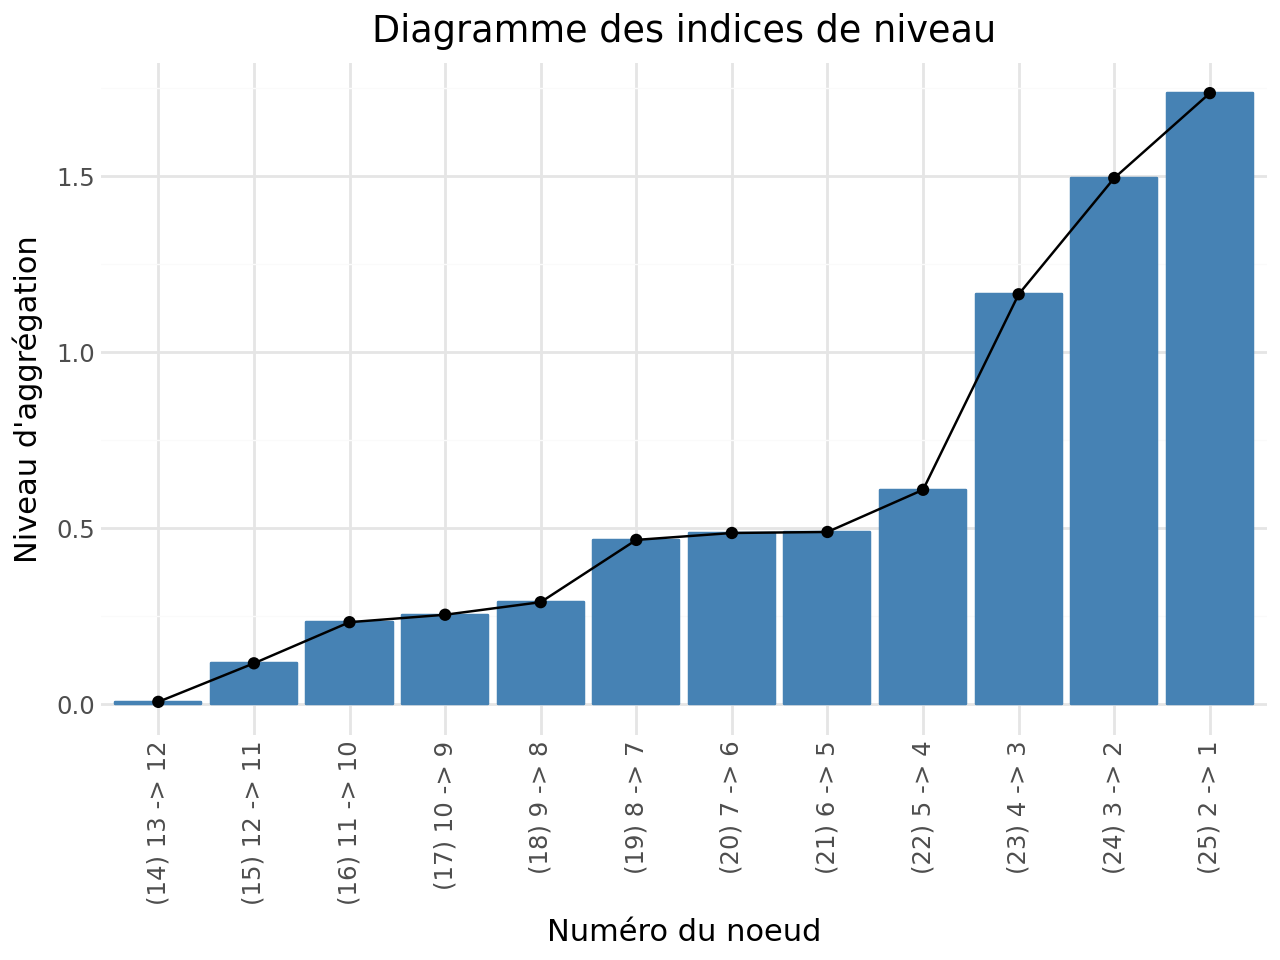

None


In [15]:
# graph of height
p = fviz_height(clf)
print(p.show())

## Supplementary variables informations

In [16]:
# supplementary variables informations
var_sup_ = clf.quanti_var_sup_
var_sup_._fields

('cluster', 'diss', 'member')

### Cluster

In [17]:
# cluster
var_sup_.cluster.to_frame()

,cluster
Crime.rate,2


### Cluster dissimilarities

In [18]:
# cluster dissimilarities
var_sup_.diss

,1,2,3,4
Crime.rate,0.989122,0.470474,0.873261,0.939951


### Cluster member

In [19]:
# cluster member
var_sup_.member.sort_values(by=["Cluster","Variable"])

,Variable,Cluster,Own Cluster,Next Closest,Ratio (Own/Next)
0,Crime.rate,2,0.470474,0.873261,0.538755


## Summary

In [20]:
# summary
from clustvartools import summary
summary(clf)

                     Clustering of Variables - CorCLV Results                     

Cluster Dissimilarities:
                      1       2       3       4
Male14_24        0.8738  0.6577  0.9666  0.3437
Southern.states  0.9931  0.8415  0.6186  0.2141
Education        0.9741  0.7653  0.5041  0.2182
Expend60         0.9865  0.0435  0.9774  0.5981
Expend59         0.9907  0.0483  0.9841  0.5840
Labor.force      0.7790  0.9948  0.1318  0.7869
Male             0.9283  0.9813  0.1318  0.8974
Pop.size         0.9641  0.3474  0.7925  0.9794
Non.white        0.9961  0.9635  0.7188  0.2575
Unemp14_24       0.0785  0.9957  0.9799  0.9787

Cluster Members and Dissimilarities values:
          Variable Cluster Own Cluster Next Closest Ratio (Own/Next)
0        Male14_24       4    0.343688     0.657702         0.522559
1  Southern.states       4    0.214147     0.618636          0.34616
2        Education       4    0.218248     0.504088         0.432956
3         Expend60       2    0.043478    

In [21]:
# markdown formatting
summary(clf,to_markdown=True)

                     Clustering of Variables - CorCLV Results                     

Cluster Dissimilarities:
                      1       2       3       4
---------------  ------  ------  ------  ------
Male14_24        0.8738  0.6577  0.9666  0.3437
Southern.states  0.9931  0.8415  0.6186  0.2141
Education        0.9741  0.7653  0.5041  0.2182
Expend60         0.9865  0.0435  0.9774  0.5981
Expend59         0.9907  0.0483  0.9841  0.584
Labor.force      0.779   0.9948  0.1318  0.7869
Male             0.9283  0.9813  0.1318  0.8974
Pop.size         0.9641  0.3474  0.7925  0.9794
Non.white        0.9961  0.9635  0.7188  0.2575
Unemp14_24       0.0785  0.9957  0.9799  0.9787

Cluster Members and Dissimilarities values:
    Variable           Cluster    Own Cluster    Next Closest    Ratio (Own/Next)
--  ---------------  ---------  -------------  --------------  ------------------
 0  Male14_24                4      0.343688         0.657702           0.522559
 1  Southern.states       